# Создание модели нейронной сети средствами Tensorflow

Библиотека <code>TensorFlow</code> предоставляет очень широкие возможности для работы с нейронными сетями. Ознакомиться со всеми возможностями можно заглянув в [официальную документацию](https://www.tensorflow.org/tutorials?hl=ru). В рамках данной же работы мы рассмотрим лишь некоторый функционал для работы с полносвязными НС.

Импортируем библиотеки

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import tensorflow as tf

# Немного про тензоры

С точки зрения `TF`, тензор — это многомерный массив. Подобно объектам `ndarray NumPy`, объекты `tf.Tensor` характеризуются типом данных и формой. В `TensorFlow` предусмотрен некоторый список готовых операций над тензорами (например, `tf.math.add`, `tf.linalg.matmul` и `tf.linalg.inv`). Эти операции автоматически преобразуют встроенные типы Python.

In [10]:
print(tf.math.add(1, 2))
print(tf.math.add([1, 2], [3, 4]))
print(tf.math.square(5))

tf.Tensor(3, shape=(), dtype=int32)
tf.Tensor([4 6], shape=(2,), dtype=int32)
tf.Tensor(25, shape=(), dtype=int32)


Преобразование `tf` ⟶ `np` и обратно происходит бесшовно

In [11]:
ndarray = np.ones([3, 3])
tensor = tf.math.reduce_sum(ndarray, [0,1])
print(tensor)

tf.Tensor(9.0, shape=(), dtype=float64)


In [12]:
np.add(tensor, 1)

np.float64(10.0)

## Типы тензоров

`tf.constant()`: Создает тензор с фиксированными значениями. Подходит, когда нужно создать тензор с известными данными.

In [13]:
tensor1 = tf.constant([1, 2, 3], dtype=tf.int32) # Целочисленный тензор
tensor2 = tf.constant([[1.0, 2.0], [3.0, 4.0]], dtype=tf.float32) # Тензор с плавающей точкой
tensor3 = tf.constant("Hello, TensorFlow!", dtype=tf.string) # Строковый тензор

print(tensor1)
print(tensor2)
print(tensor3)

tf.Tensor([1 2 3], shape=(3,), dtype=int32)
tf.Tensor(
[[1. 2.]
 [3. 4.]], shape=(2, 2), dtype=float32)
tf.Tensor(b'Hello, TensorFlow!', shape=(), dtype=string)


`tf.Variable()`: Создает тензор, который можно изменять. Обычно используется для хранения весов и смещений в моделях.

In [14]:
variable1 = tf.Variable([1.0, 2.0], dtype=tf.float32)
print(variable1)
variable1.assign([3.0, 4.0]) # Изменение значения переменной
print(variable1)

<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([1., 2.], dtype=float32)>
<tf.Variable 'Variable:0' shape=(2,) dtype=float32, numpy=array([3., 4.], dtype=float32)>


Кроме того, из названий понятно, для чего используются следующие типы тензоров:


*   tf.zeros()
*   tf.ones()
*   tf.random.normal()
*   tf.random.uniform()
*   tf.convert_to_tensor()



# Чтение и предварительная обработка данных

В качестве набора данных рассмотрим [следующий датасет.](https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Howell1.csv)

Это демографические данные жителей пустыни Калахари (охотники-собиратели), собранные Нэнси Хауэлл в Ботсване в период с августа 1967 по май 1969 года.

Считаем данные. Отберем относительно "стандартных" людей в возрасте от 18 до 50 лет.  

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/rmcelreath/rethinking/master/data/Howell1.csv', sep=';')
df_sample = df[(df['age'] >= 18) & (df['age'] <= 50)]
df_sample.head()

,height,weight,age,male
3,156.845,53.041914,41.0,1
5,163.830,62.992589,35.0,1
6,149.225,38.243476,32.0,0
7,168.910,55.479971,27.0,1
8,147.955,34.869885,19.0,0


В качестве признаков будем рассматривать рост (<code>height</code>) и вес (<code>weight</code>), а предсказывать будем пол (<code>male</code>).

Визуализируем данные

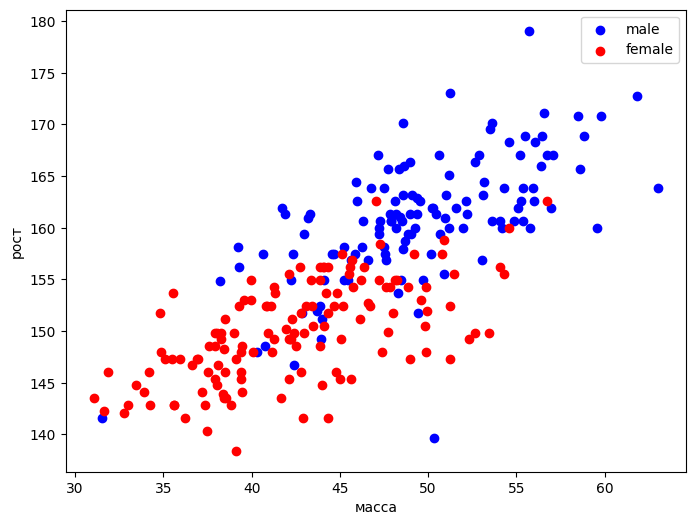

In [16]:
def plot(df):
    plt.figure(figsize=(8,6))
    plt.scatter(df.weight[df.male == 1], df.height[df.male == 1], color='blue', label='male')
    plt.scatter(df.weight[df.male == 0], df.height[df.male == 0], color='red', label='female')
    plt.legend()
    plt.ylabel('рост')
    plt.xlabel('масса')
plot(df_sample)

Разделим набор данных на тренировочную и тестовую части, а также зафиксируем <code>random_state</code> для воспроизводимости результатов.

In [17]:
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(df_sample[['weight', 'height']], df_sample['male'], test_size=0.2, random_state=random_state)

Приведем данные к необходимому формату. Во-первых `TF`привередлив к типам данных, во-вторых, отклики как одномерный массив "не катят", иначе будут проблемы (попробуйте убрать `.reshape(-1, 1)` для откликов).

In [18]:
X_train = X_train.to_numpy(dtype=np.float32)
y_train = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
X_test = X_test.to_numpy(dtype=np.float32)
y_test = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

Раз мы имеем дело с нейронной сетью, имеет смысл нормировать данные.

In [19]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
X_test[:5]

array([[-1.012742  ,  0.35883963],
       [-0.69347304, -0.14755596],
       [ 0.20668836,  0.94963145],
       [ 0.6634202 , -0.45476642],
       [-0.7200788 , -0.40075275]], dtype=float32)

# Проектирование модели

Зададим гиперпараметры

In [20]:
# Количество входных признаков
input_size = 2
# Количество выходных классов (бинарная классификация)
output_size = 1
# Размер батча
batch_size = len(X_train)
# Скорость обучения
learning_rate = 0.5
# Количество эпох
epochs = 1000

Инициализируем переменные для весов и смещения

In [21]:
tf.random.set_seed(random_state)
W = tf.Variable(tf.random.normal(shape=(input_size, output_size), dtype=tf.float32))
b = tf.Variable(tf.zeros(shape=(output_size,), dtype=tf.float32))

Функция активации

In [22]:
def sigmoid(x):
    return 1 / (1 + tf.exp(-x))

Определим лосс

In [23]:
def BCE(y_true, y_pred):
    return -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

Прямой проход

In [24]:
def forward_pass(X):
    linear_output = tf.matmul(X, W) + b
    return sigmoid(linear_output)

Шаг обучения

In [25]:
def train_step(X, y):
    with tf.GradientTape() as tape:
        # Прямой проход
        y_pred = forward_pass(X)
        # Вычисление потерь
        loss = BCE(y, y_pred)

    # Вычисление градиентов
    gradients = tape.gradient(loss, [W, b])

    # Обновление весов и смещений
    W.assign_sub(learning_rate * gradients[0])
    b.assign_sub(learning_rate * gradients[1])

    return loss


*   `tf.GradientTape()`: Это контекстный менеджер, который "записывает" все операции, выполненные внутри него, для последующего вычисления градиентов.
*   `tape.gradient(loss, [W, b])`: Вычисляет градиенты функции потерь loss относительно переменных W (веса) и b (смещение).
*   `W.assign_sub(learning_rate * gradients[0])` и `b.assign_sub()`: Обновляют значения весов и смещений с использованием градиентного спуска. assign_sub вычитает указанное значение из текущего значения переменной.
*   `tf.data.Dataset`: Используется для создания итерируемого объекта из данных, который позволяет эффективно обрабатывать большие наборы данных, разделяя их на пакеты.



Цикл обучения

In [26]:
# Создание набора данных TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)

history = []

# Цикл по эпохам
for epoch in range(epochs):
    epoch_loss = 0.0
    # Цикл по пакетам данных
    for X_batch, y_batch in dataset:
        loss = train_step(X_batch, y_batch)
        epoch_loss += loss.numpy()
    history.append(epoch_loss)
    # Вывод информации о прогрессе обучения
    if epoch % int(epochs/10) == 0:
      print(f"Эпоха {epoch+1}, Loss: {epoch_loss / len(dataset)}")

Эпоха 1, Loss: 0.9534430503845215
Эпоха 101, Loss: 0.35088101029396057
Эпоха 201, Loss: 0.34261974692344666
Эпоха 301, Loss: 0.34134382009506226
Эпоха 401, Loss: 0.3410964012145996
Эпоха 501, Loss: 0.34104400873184204
Эпоха 601, Loss: 0.3410325050354004
Эпоха 701, Loss: 0.34102994203567505
Эпоха 801, Loss: 0.3410293459892273
Эпоха 901, Loss: 0.34102922677993774


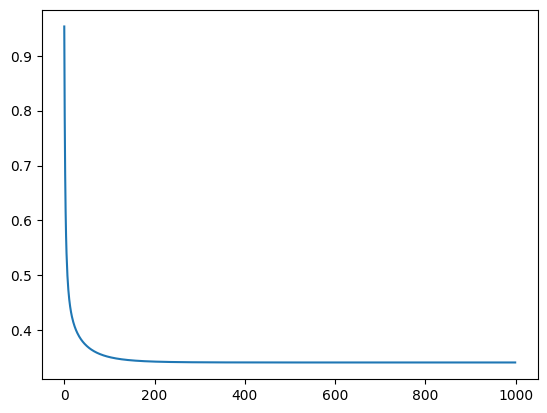

In [27]:
plt.plot(range(len(history)), history)

In [28]:
W

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[-0.25909093],
       [ 3.1751053 ]], dtype=float32)>

In [29]:
b

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([-0.11246528], dtype=float32)>

Оценка модели

In [65]:
def predict(X):
  return np.array([1 if _ > 0.5 else 0 for _ in forward_pass(X)])

y_pred = predict(X_test)
f1_score(y_test, y_pred)

0.8181818181818182

# Больше коробочных решений

Очевидно, что в `TF` уже реализованы многие компоненты, которые мы до этого писали "руками".

In [31]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.losses import BinaryCrossentropy

Функция активации

In [32]:
def sigmoid(x):
    return tf.nn.sigmoid(x)

Лосс

In [33]:
BCE = BinaryCrossentropy()

Оптимизатор

In [34]:
optimizer = SGD(learning_rate=learning_rate)

In [35]:
def forward_pass(X):
    linear_output = tf.matmul(X, W) + b
    return sigmoid(linear_output)

Собираем все вместе + используем декоратор `@tf.function`. Это позволяет компилировать Python-функцию в graph `TensorFlow`, что значительно ускоряет выполнение кода, особенно на GPU и TPU.

In [36]:
@tf.function
def train_step(X, y):
    with tf.GradientTape() as tape:
        y_pred = forward_pass(X)
        loss = BCE(y, y_pred)

    gradients = tape.gradient(loss, [W, b])

    # Обновление весов и смещений (теперь через оптимизатор)
    optimizer.apply_gradients(zip(gradients, [W, b]))

    return loss

In [37]:
tf.random.set_seed(random_state)
W = tf.Variable(tf.random.normal(shape=(input_size, output_size), dtype=tf.float32))
b = tf.Variable(tf.zeros(shape=(output_size,), dtype=tf.float32))

In [38]:
# Создание набора данных TensorFlow
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)

history = []

# Цикл по эпохам
for epoch in range(epochs):
    epoch_loss = 0.0
    # Цикл по пакетам данных
    for X_batch, y_batch in dataset:
        loss = train_step(X_batch, y_batch)
        epoch_loss += loss.numpy()
    history.append(epoch_loss)
    # Вывод информации о прогрессе обучения
    if epoch % int(epochs/10) == 0:
      print(f"Эпоха {epoch+1}, Loss: {epoch_loss / len(dataset)}")

Эпоха 1, Loss: 0.9534430503845215
Эпоха 101, Loss: 0.35088101029396057
Эпоха 201, Loss: 0.34261974692344666
Эпоха 301, Loss: 0.34134382009506226
Эпоха 401, Loss: 0.3410964012145996
Эпоха 501, Loss: 0.34104400873184204
Эпоха 601, Loss: 0.3410325050354004
Эпоха 701, Loss: 0.34102994203567505
Эпоха 801, Loss: 0.3410293459892273
Эпоха 901, Loss: 0.34102922677993774


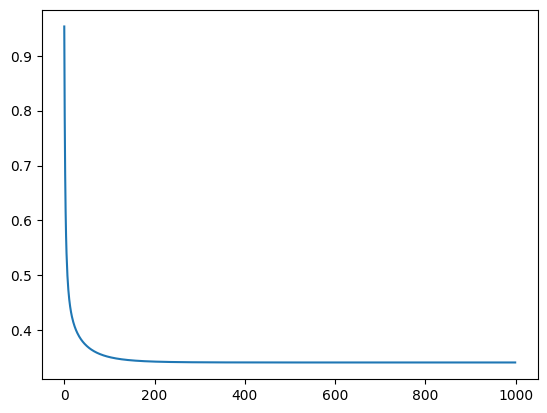

In [39]:
plt.plot(range(len(history)), history)

In [40]:
W

<tf.Variable 'Variable:0' shape=(2, 1) dtype=float32, numpy=
array([[-0.25909105],
       [ 3.1751056 ]], dtype=float32)>

In [41]:
def predict(X):
  return np.array([1 if _ > 0.5 else 0 for _ in forward_pass(X)])

y_pred = predict(X_test)
f1_score(y_test, y_pred)

0.8181818181818182

# Keras

## Небольшое описание

Раньше `Keras` был самостоятельной библиотекой для работы с НС на очень высоком уровне абстракции (в тч с `TF`), но затем стал частью `TF`. `Keras` предназначен для упрощения разработки моделей и решения повседневных (для нейросетей) задач. В случае исследовательских работ или построения сложных схем лучше делать это на уровне `TensorFlow` — с использованием тензоров, самостоятельно определяя слои и способы их соединения. `Keras` же помогает быстро построить модель и обучить ее, используя одну из заранее составленных архитектур, или построив простую архитектуру самостоятельно.






In [42]:
from tensorflow import keras

На высоком уровне абстрации, рецепт для "приготовления" нейронной сети достаточно прост: нужны следующие ингридиенты:


*   **Архитектура** (слои и функции активации в них)
*   **Лосс**
*   **Оптимизатор**
*   **Метрика** (опционально)

![Логотип Python](https://storage.yandexcloud.net/lms-itmo-ru-files-27a87tyf/SMILE_data/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F%20image.png)

Давайте посмотрим, где и как в пакете `Keras` расположены необходимые нам элементы.
К текущему моменту мы пока что рассмотрили только один тип слоев — полносвязный, однако в дальнейшей в рамках курса мы с вами изучим и другие. Все слои располагаются в модуле `layers`.

In [43]:
from tensorflow.keras import layers

Кроме того, мы с вами изучили некоторые функции активации, которые можно использовать при построении нейронных сетей. Все функции активации расположены в пакете `activations`.

In [44]:
from tensorflow.keras import activations

Также импортируем пакет `optimizers`, в котором расположены оптимизаторы для обучения.

In [45]:
from tensorflow.keras import optimizers

В модуле `losses` расположены различные функции потерь, которые можно использовать для обучения.

In [46]:
from tensorflow.keras import losses

И последнее, что нам понадобится импортировать — это метрики из пакета `metrics`. Функция потерь — это некоторая функция, которая возвращает абстрактный `loss`, по которому сложно и зачастую совершенно невозможно оценить качество модели. Для измерения метрик, понятных людям, воспользуемся модулем `metrics` и заданными там функциями.

In [47]:
from tensorflow.keras import metrics

## Вернемся к модели

**Модель**:

*   Архитектура:
    +   Входной слой
    +   1 нейрон, функция активации -- сигмоида
*   Лосс: BCE
*   Оптимизатор: Градиентный спуск
*   Метрика: f1_score

In [48]:
# Тип модели: последовательная
model = keras.Sequential()

In [49]:
# Добавляем входной слой
model.add(layers.Input(shape=X_train.shape[1:]))

In [50]:
# Добавляем слой и функцию активации
model.add(layers.Dense(1, activation=activations.sigmoid))

In [51]:
# Оптимизатор, лосс, метрика
model.compile(
    optimizer = optimizers.SGD(learning_rate = 0.5),
    loss = losses.BinaryCrossentropy(),
    metrics = [metrics.F1Score()]
)

In [52]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Обучение

In [67]:
history = model.fit(X_train, y_train, epochs=1000, batch_size=len(X_train), verbose=0)

Отследить обучение можно по `history`

In [54]:
history.history.keys()

dict_keys(['f1_score', 'loss'])

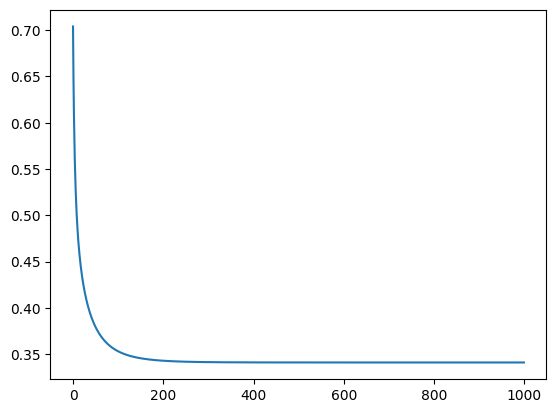

In [55]:
plt.plot(range(len(history.history['loss'])), history.history['loss'])

### Более краткая запись

In [56]:
# Архитектура

model_short = keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(1, activation='sigmoid')
])

In [57]:
# Оптимизатор, лосс, метрика

model_short.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['f1_score'])

In [58]:
model_short.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

### Предсказания и оценка

In [59]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)
f1_score(y_test, y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


0.8181818181818182

Можно также посмотреть на сами веса

In [60]:
model.layers[0].weights

[<Variable path=sequential/dense/kernel, shape=(2, 1), dtype=float32, value=[[-0.25905  ]
  [ 3.1750343]]>,
 <Variable path=sequential/dense/bias, shape=(1,), dtype=float32, value=[-0.11246422]>]

## Многослойная НС

Аналогично рассмотренному выше создайте теперь многослойную сеть со следующей структурой скрытых слоев (число нейронов): `(256, 128, 64)`.

*   Функция активации в скрытых слоях — `relu`.
*   Активация выходного слоя `sigmoid`
*   Лосс — `binary_crossentropy`
*   Оптимизатор — стохастический градиентный спуск (`batch_size=32`)
*   Число эпох обучения — `100`

Обучите модель на тренировочных данных, оцените на тестовых. Удалось ли существенно увеличить значение метрики?

Исследуйте варианты с более сложной/простой архитектурой, и другими  гиперпараметрами.



In [61]:
model_mlp = keras.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_mlp.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['f1_score'])

In [62]:
history = model_mlp.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

In [63]:
y_pred_proba = model_mlp.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)
f1_score(y_test, y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step


0.8

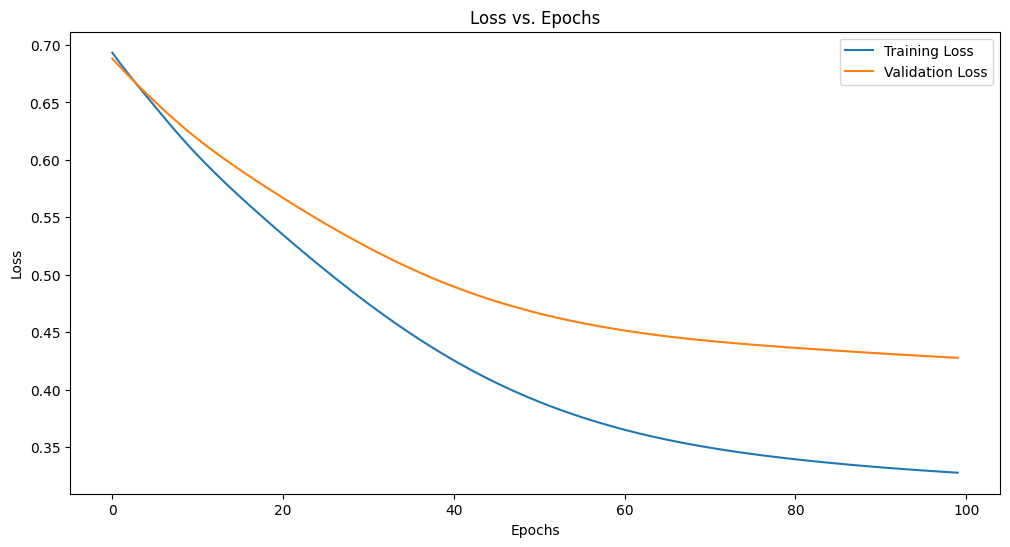

In [64]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()